In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set()

2024-11-24 15:23:35.230287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-24 15:23:35.243875: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-24 15:23:35.248017: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-24 15:23:35.949907: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
adata_sp_gas=sc.read_visium('/mnt/data/zehuazeng/result/GC_ST/HRR742264/HRR742264/outs/')
adata_sp_gas.obs.index=[f'gas:{i}' for i in adata_sp_gas.obs.index]

reading /mnt/data/zehuazeng/result/GC_ST/HRR742264/HRR742264/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


In [3]:
adata_sp_gc=sc.read_visium('data/GC_ST/GSE245704_RAW')
adata_sp_gc.obs.index=[f'gc:{i}' for i in adata_sp_gc.obs.index]

reading data/GC_ST/GSE245704_RAW/filtered_feature_bc_matrix.h5
 (0:00:00)


In [4]:
adata_sp_gc.var_names_make_unique()
adata_sp_gas.var_names_make_unique()

In [5]:
adata_sp_gas,adata_sp_gc

(AnnData object with n_obs × n_vars = 2325 × 36601
     obs: 'in_tissue', 'array_row', 'array_col'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatial'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 2560 × 18085
     obs: 'in_tissue', 'array_row', 'array_col'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatial'
     obsm: 'spatial')

In [6]:
adatas_cor=[adata_sp_gas,adata_sp_gc]

In [7]:
adata_spatial = sc.concat(
    adatas_cor,
    label="library_id",
    uns_merge="unique",
    keys=[
        k
        for d in [
            adatas_cor[0].uns["spatial"],
            adatas_cor[1].uns["spatial"],
        ]
        for k, v in d.items()
    ],
    #index_unique="-",
)
adata_spatial.obs.head()

,in_tissue,array_row,array_col,library_id
gas:AAACAAGTATCTCCCA-1,1,50,102,HRR742264
gas:AAACCGGAAATGTTAA-1,1,54,124,HRR742264
gas:AAACCGGGTAGGTACC-1,1,42,28,HRR742264
gas:AAACCGTTCGTCCAGG-1,1,52,42,HRR742264
gas:AAACCTAAGCAGCCGG-1,1,65,83,HRR742264


In [8]:
adata=adata_spatial

In [9]:
#This step sometimes needs to be run twice
#and you need to check that adata.obs['X'] is correctly assigned instead of NA
adata.obs['x'] = adata.obsm['spatial'][:,0]
adata.obs['y'] = adata.obsm['spatial'][:,1]
adata.obs['x'][0]

3277.746605932137

In [10]:
adata.layers['norm_1e4'] = sc.pp.normalize_total(adata, target_sum=1e4, 
                                                 inplace=False)['X'].toarray() # we use normalized counts for each cell as input gene expression


normalizing counts per cell
    finished (0:00:00)


In [11]:
adata.obs['sample']=adata.obs['library_id']

In [12]:
import numpy as np
# Get the coordinates and expression data for each sample
samples = np.unique(adata.obs['sample']) # used samples in adata
coords_raw = {sample_t: np.array(adata.obs[['x','y']])[adata.obs['sample'] == sample_t] for sample_t in samples}
exp_dict = {sample_t: adata[adata.obs['sample'] == sample_t].layers['norm_1e4'] for sample_t in samples}

Constructing delaunay graphs for 2 samples...
Training on cuda:0...


Loss: -395.653 step time=0.091s: 100%|██████████| 400/400 [00:36<00:00, 10.91it/s]


Finished.
The embedding, log, model files were saved to result/CAST_gas/output


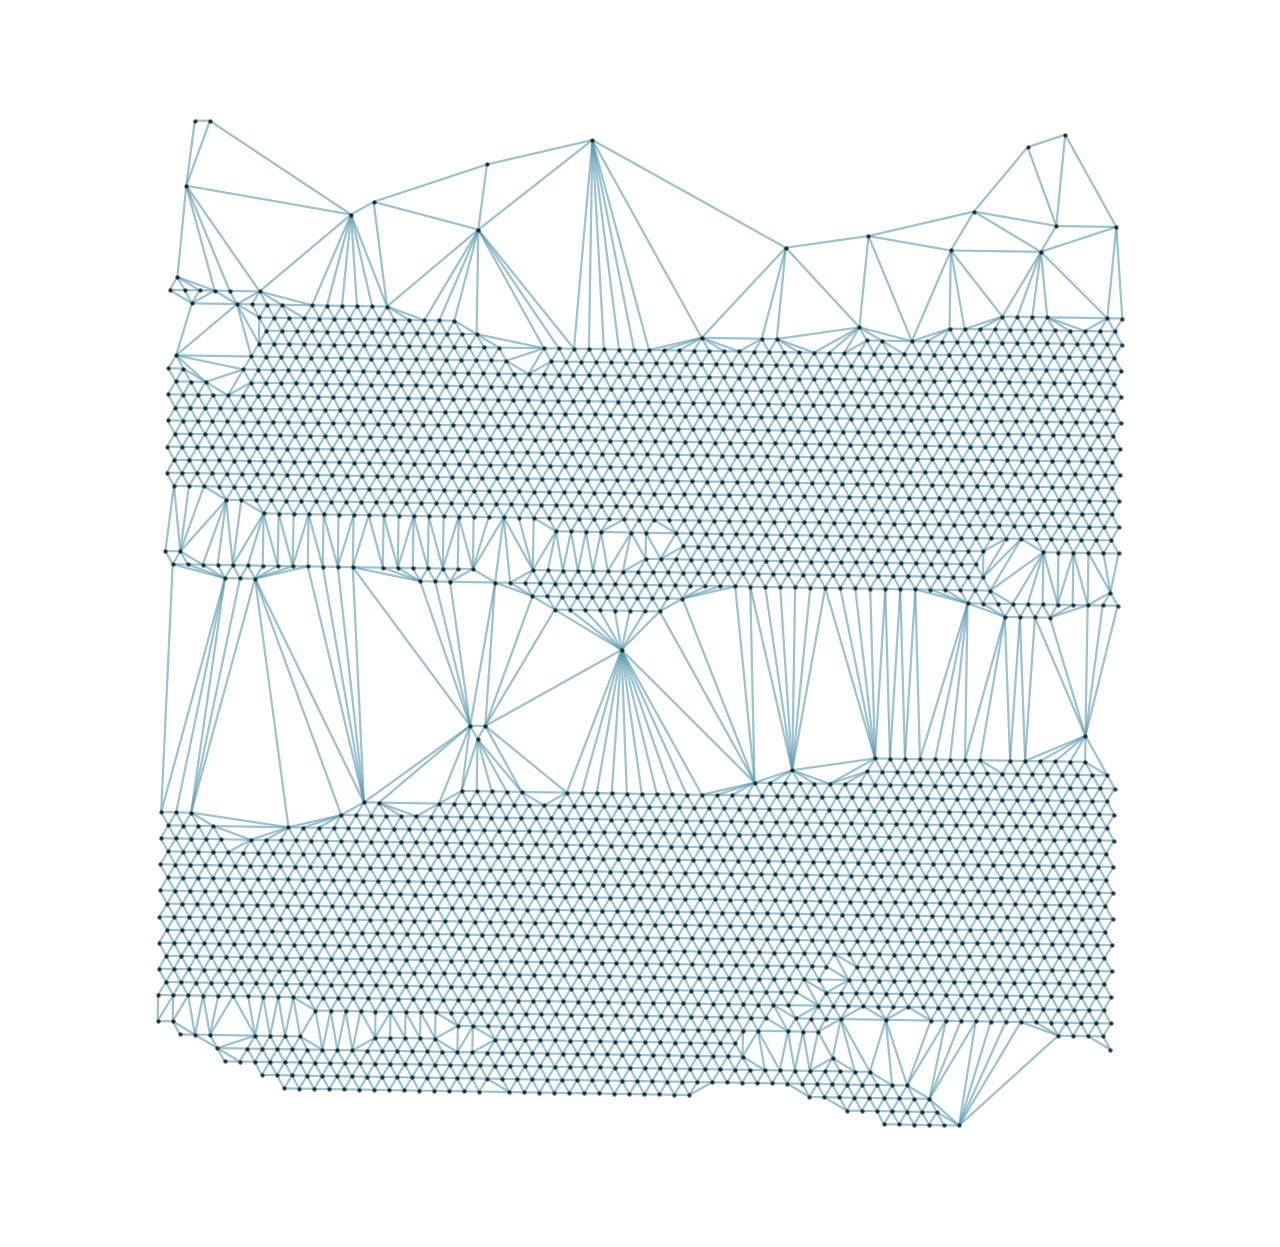

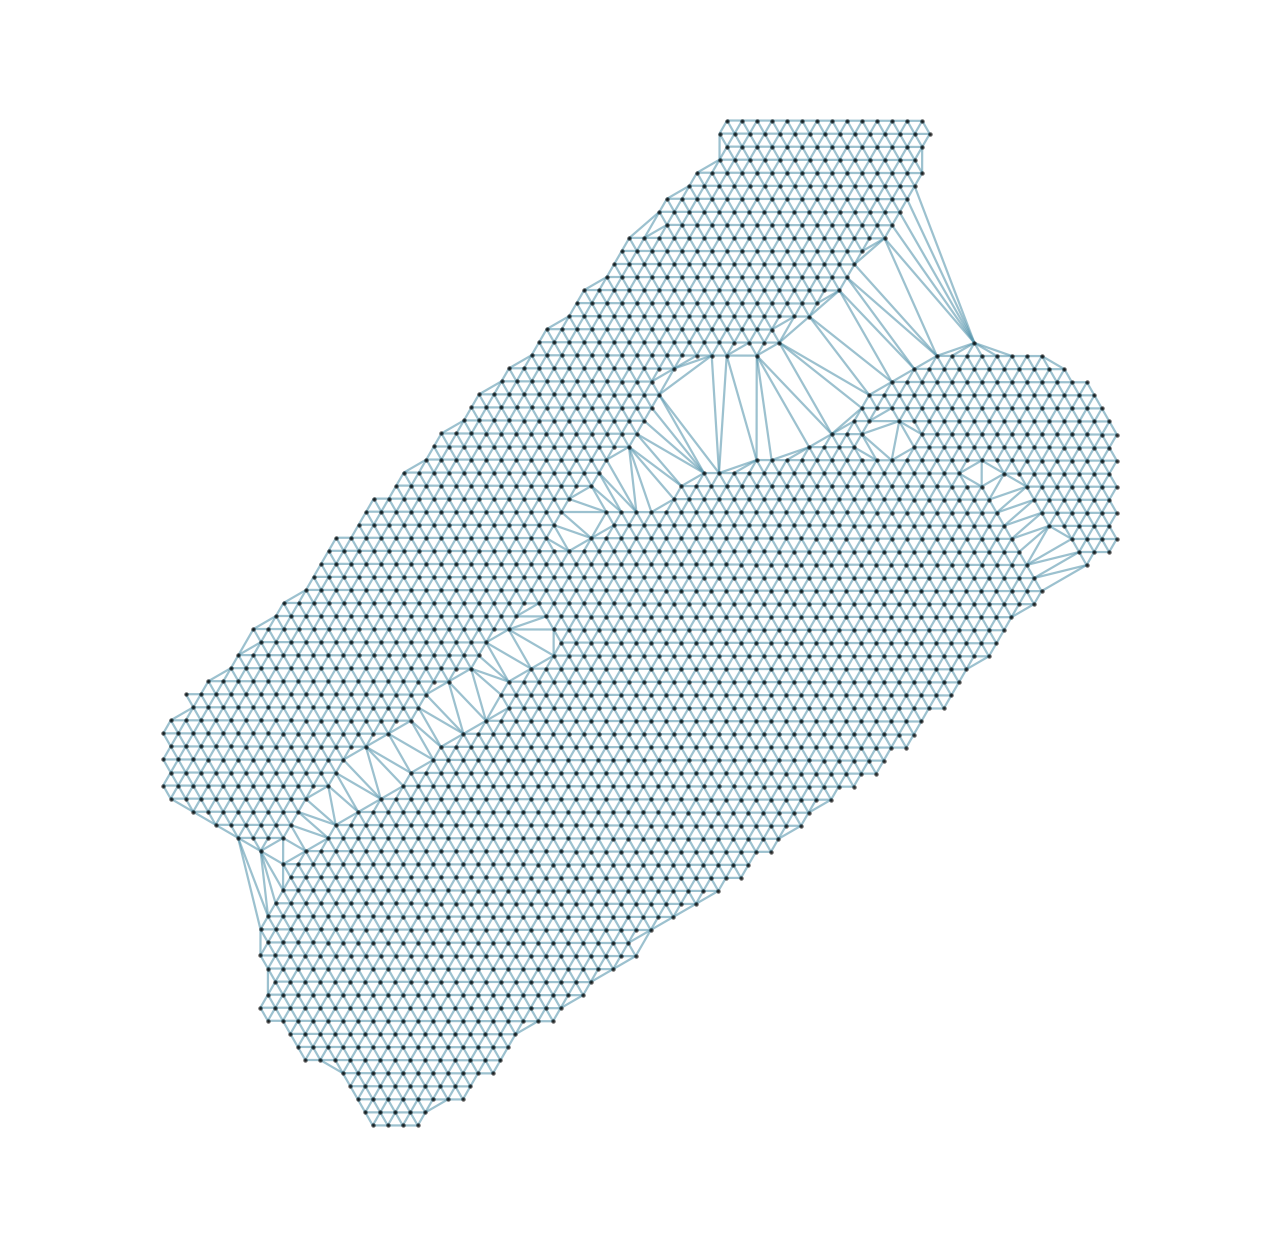

In [13]:
### Run the model to generate the graph embedding
# Set up the output path
import os
output_path = f'result/CAST_gas/output'
os.makedirs(output_path, exist_ok=True)

from omicverse.externel.CAST import CAST_MARK
embed_dict = CAST_MARK(coords_raw,exp_dict,output_path,gpu_t=0,device='cuda:0')

Perform KMeans clustering on 4885 cells...
Plotting the KMeans clustering results...


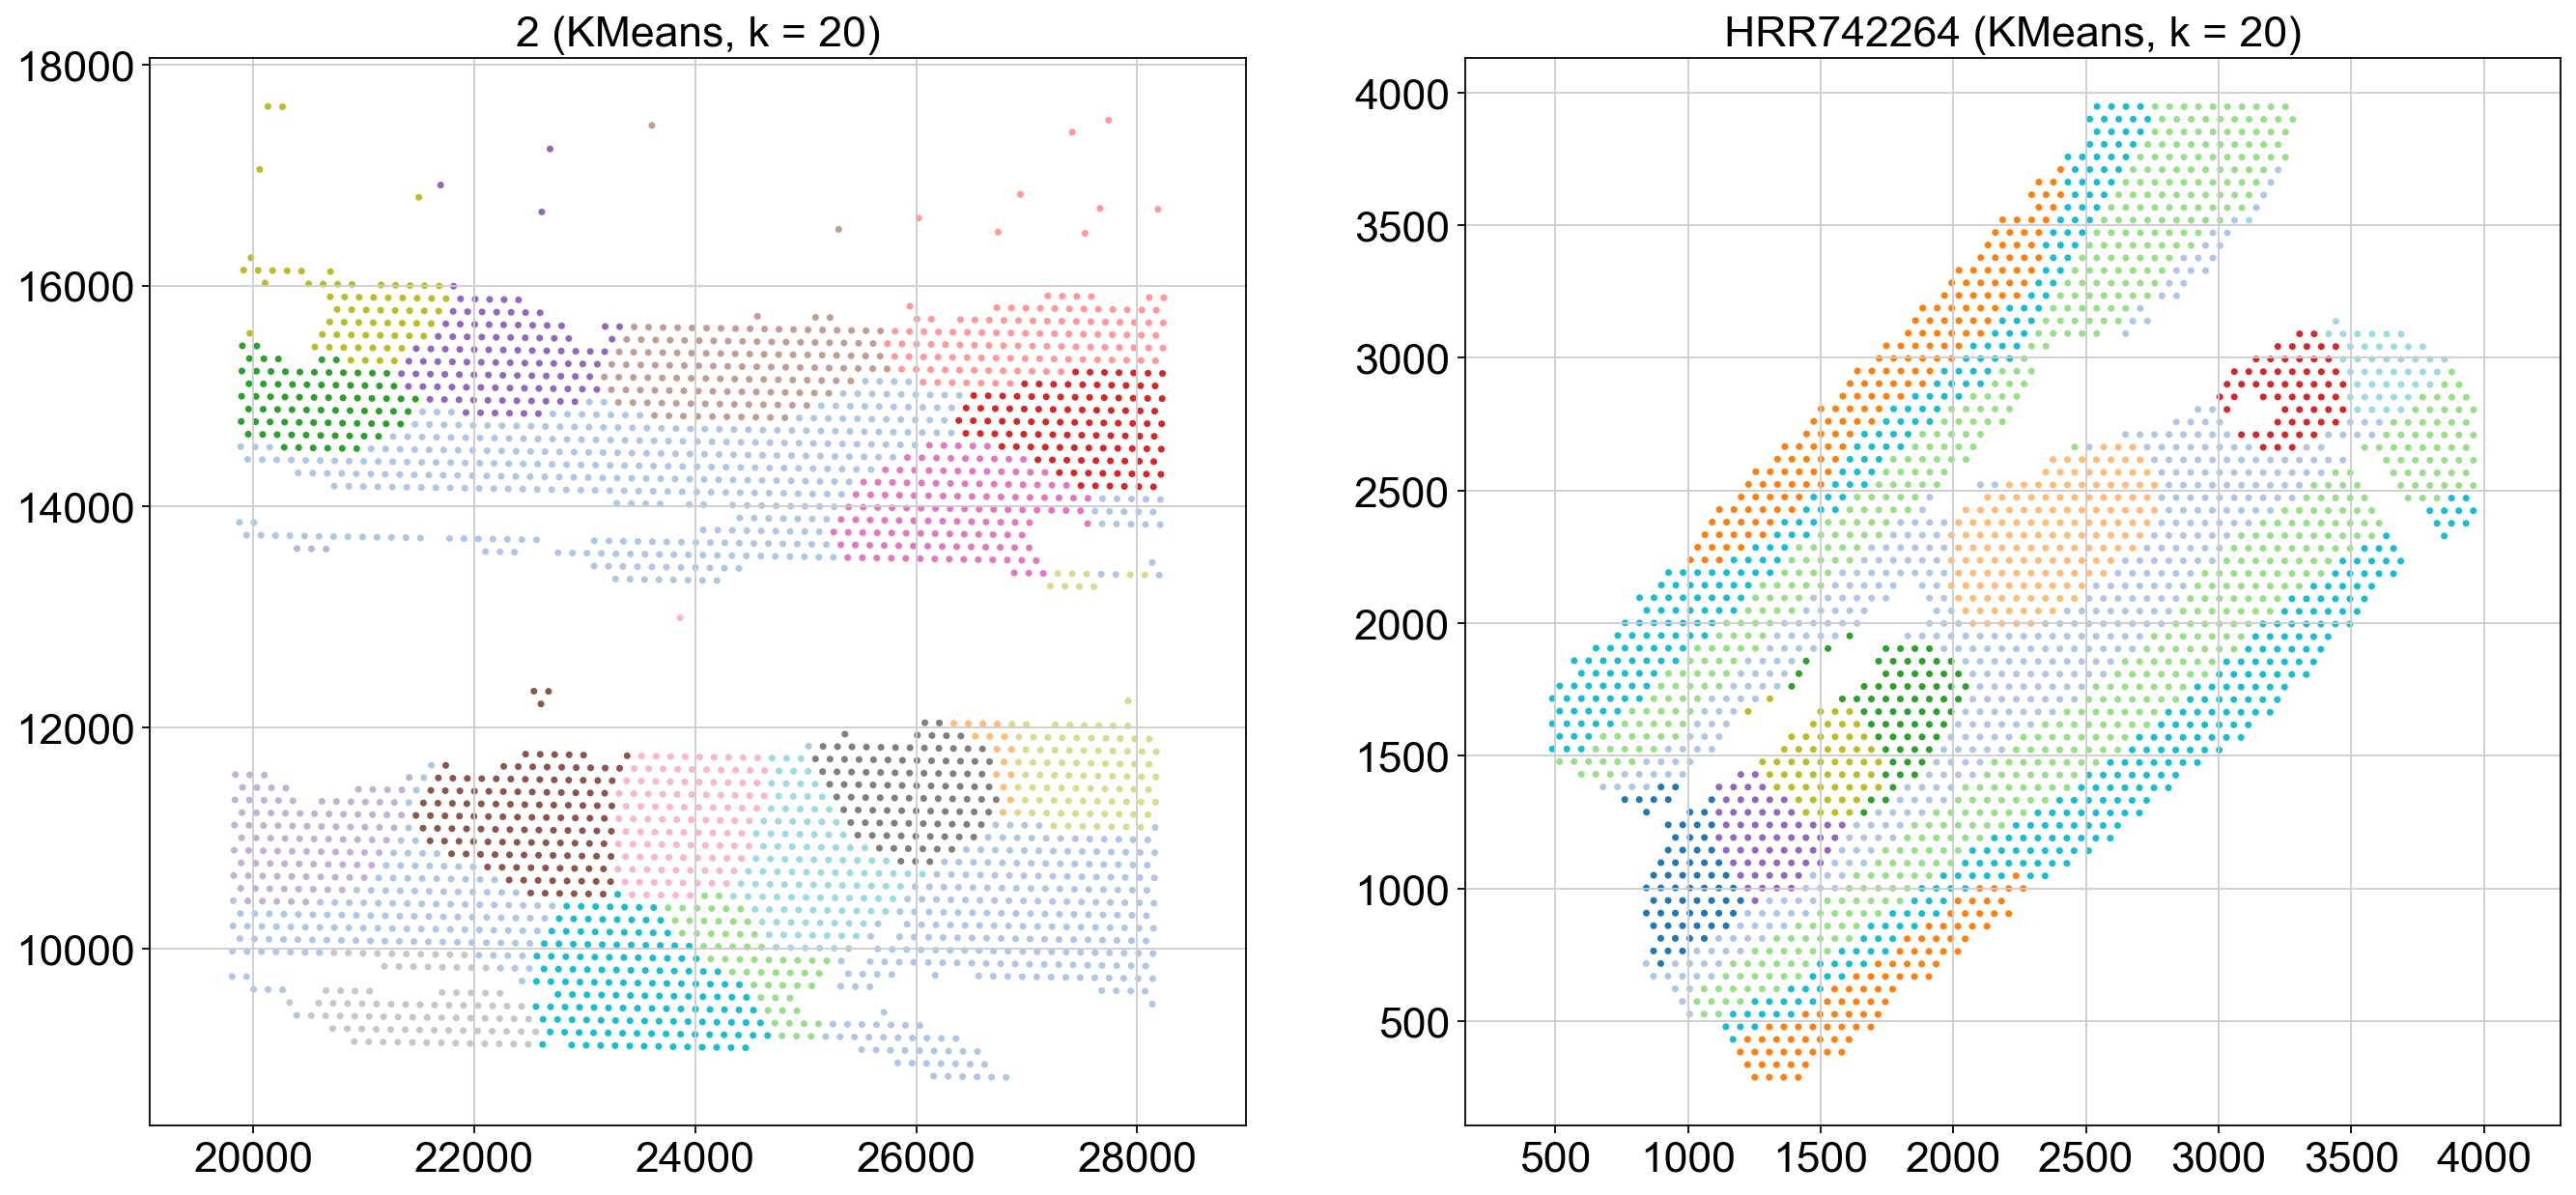

In [14]:
### Visualize the embedding with Kmeans clustering

from omicverse.externel.CAST.visualize import kmeans_plot_multiple


clusters_kmeans=kmeans_plot_multiple(embed_dict,samples,coords_raw,'demo1',output_path,
                     k=20,dot_size = 10,minibatch=False)


In [15]:
adata.obs['cast_clusters']='-1'
for idx,key in enumerate(embed_dict.keys()):
    if idx==0:
        front_idx=0
        back_idx=adata.obs.loc[adata.obs['sample']==key].shape[0]
        adata.obs.loc[adata.obs['sample']==key,'cast_clusters']=clusters_kmeans[front_idx:front_idx+back_idx]
        front_idx+=back_idx
    else:
        back_idx=adata.obs.loc[adata.obs['sample']==key].shape[0]
        adata.obs.loc[adata.obs['sample']==key,'cast_clusters']=clusters_kmeans[front_idx:front_idx+back_idx]
        front_idx+=back_idx
from tqdm import tqdm
adata.obsm['X_cast']=np.zeros((adata.shape[0],512))
import pandas as pd
adata.obsm['X_cast']=pd.DataFrame(adata.obsm['X_cast'],index=adata.obs.index)
for key in tqdm(embed_dict.keys()):
    adata.obsm['X_cast'].loc[adata.obs['sample']==key]+=embed_dict[key].cpu().numpy()
adata.obs['cast_clusters']=adata.obs['cast_clusters'].astype('category')

100%|██████████| 2/2 [00:00<00:00, 11.61it/s]


In [16]:
adata.obsm['X_cast']=adata.obsm['X_cast'].values

In [17]:
sc.pp.neighbors(adata, use_rep='X_cast')
sc.tl.umap(adata)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


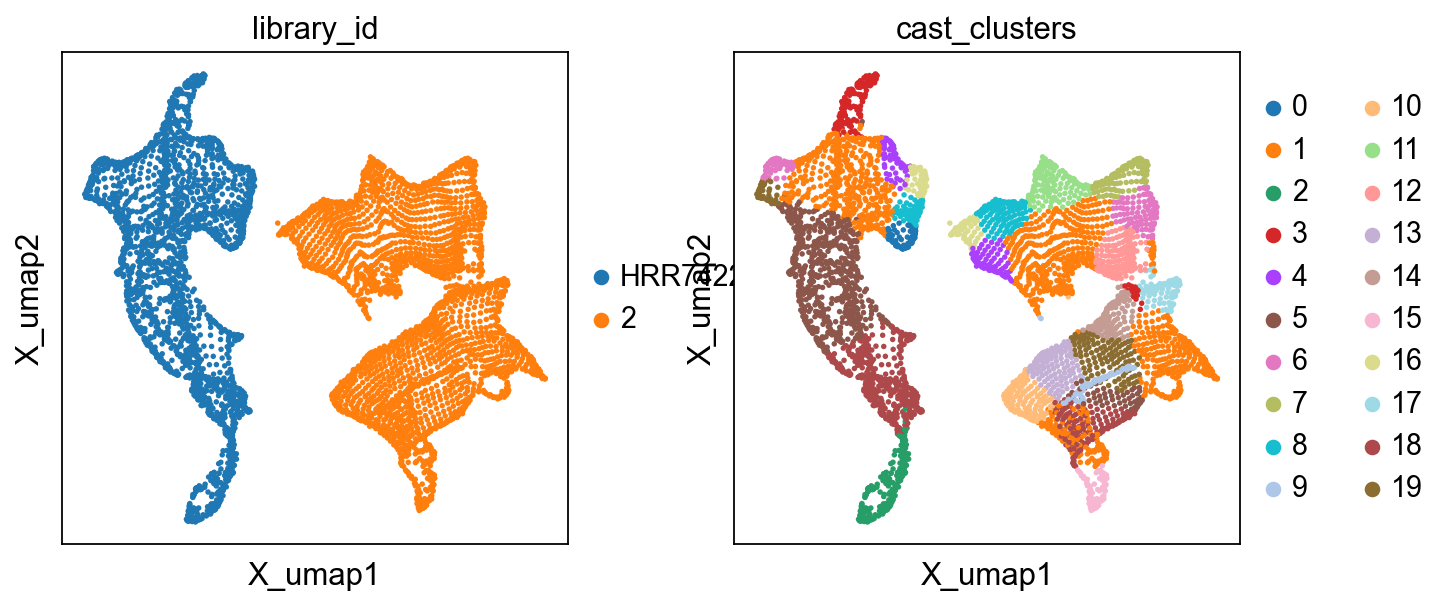

In [18]:
sc.pl.embedding(adata,
               basis='X_umap',
               color=['library_id','cast_clusters'])

In [19]:
ov.utils.cluster(adata,use_rep='X_cast',method='mclust',n_components=20,
                 modelNames='EEV', random_state=112,
                )
#adata.obs['mclust_GraphST'] = ov.utils.refine_label(adata, radius=50, key='mclust') 

running GaussianMixture clustering
finished: found 20 clusters and added
    'mclust', the cluster labels (adata.obs, categorical)


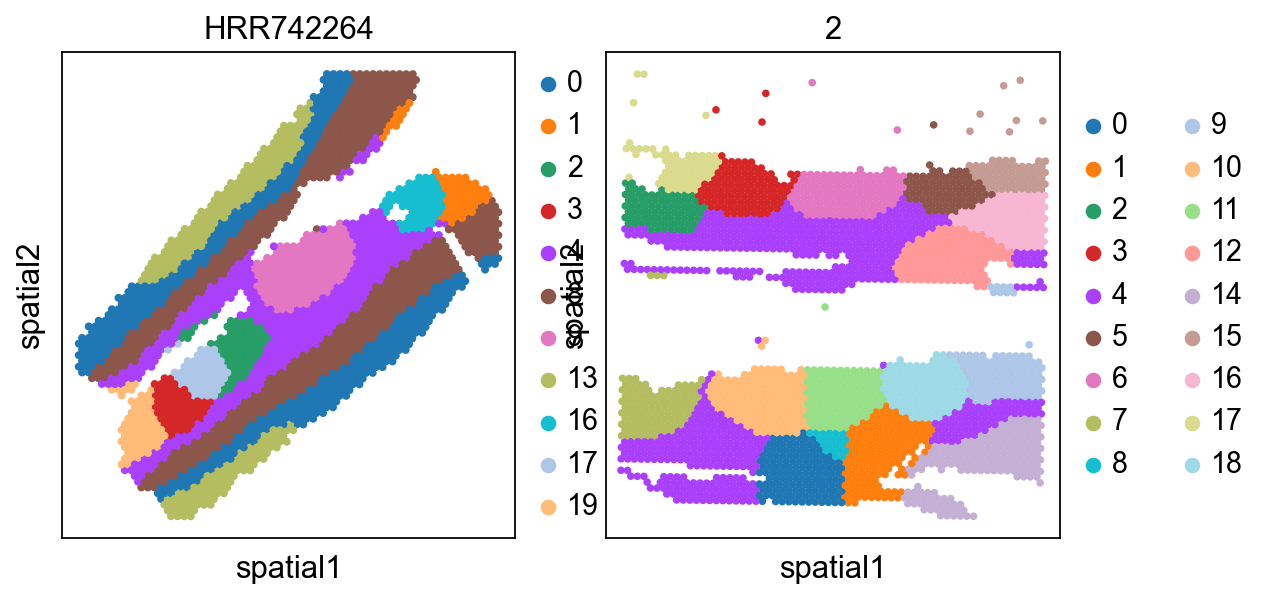

In [21]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
section_list=adata.obs['library_id'].unique()
it=0
for it,section_id in enumerate(section_list):
    ax = sc.pl.embedding(adata[adata.obs['library_id']==section_id], basis='spatial', ax=axs[it], #legend_loc=None,
                      color=["mclust"], title=section_id, show=False)
    ax.axis('equal')

In [54]:
adata_sp_gas.obs['mclust']=adata.obs.loc[adata_sp_gas.obs.index,'mclust'].tolist()
adata_sp_gc.obs['mclust']=adata.obs.loc[adata_sp_gc.obs.index,'mclust'].tolist()

In [55]:
adata_sp_gas.obs['mclust']=adata_sp_gas.obs['mclust'].astype(str)
adata_sp_gc.obs['mclust']=adata_sp_gc.obs['mclust'].astype(str)

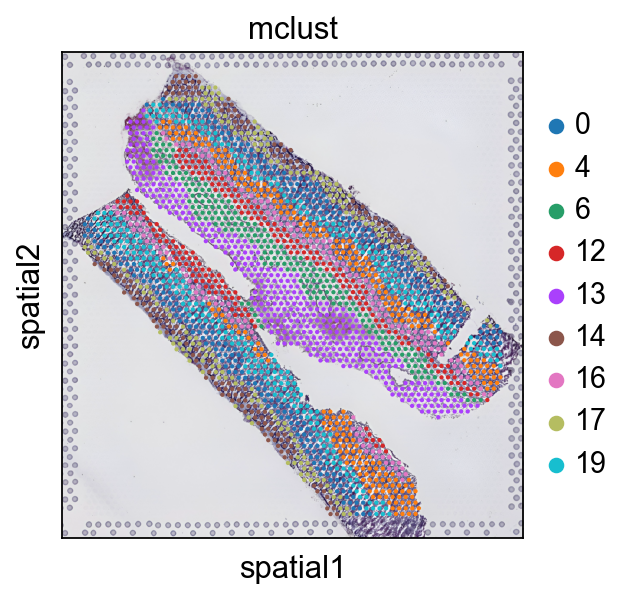

In [56]:
sc.pl.spatial(adata_sp_gas, color=['mclust'])

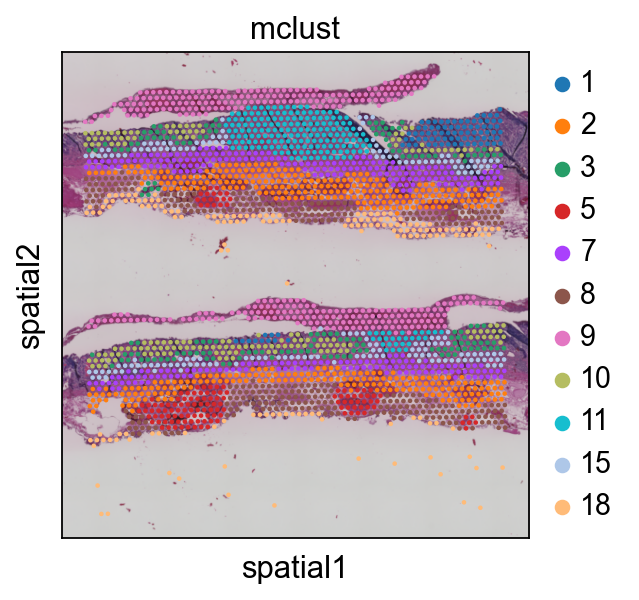

In [57]:
sc.pl.spatial(adata_sp_gc, color=['mclust'])